In [1]:
%matplotlib widget
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from mterrain.functions import univariate_peak

**Univariate Peaks**

Peak like behavior is achieved using a Lorentzian function whose graph is bell shaped:

$$f\left(x\right)=\frac{h\left(w \big/ 2\right)^2}{\left(x-c\right)^2+\left(w \big/ 2\right)^2}$$

Function parameters relate to curve shape as follows:

 - $h$ : the height of the peak at its center
 - $c$ : the center of the peak
 - $w$ : the width of the curve at half of $h$

interactive(children=(FloatSlider(value=26.0, description='Height', max=150.0, min=-150.0, step=1.1), FloatSli…

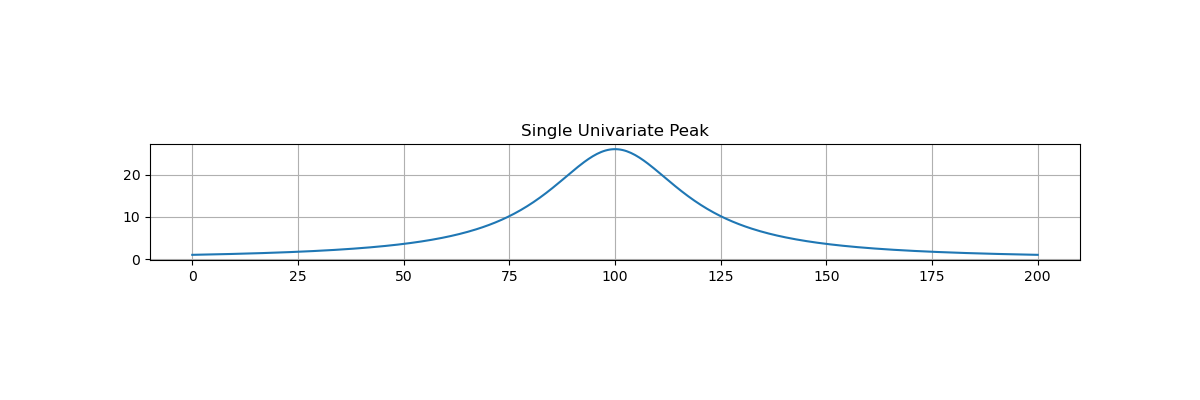

In [2]:
x = np.linspace(0, 200, 400)
f = univariate_peak(26.0, 100.0, 40.0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title("Single Univariate Peak")
line, = ax.plot(x, f(x))
ax.set_aspect('equal')
ax.grid(True)

def update(Height=26.0, Center=100.0, Width=40.0):
    f = univariate_peak(Height, Center, Width)
    line.set_ydata(f(x))
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

widgets.interact(update, Height = (-150.0, 150.0, 1.1), Center = (25.0, 175.0, 5.0), Width = (1.0, 100.0, 1.0));

Output()

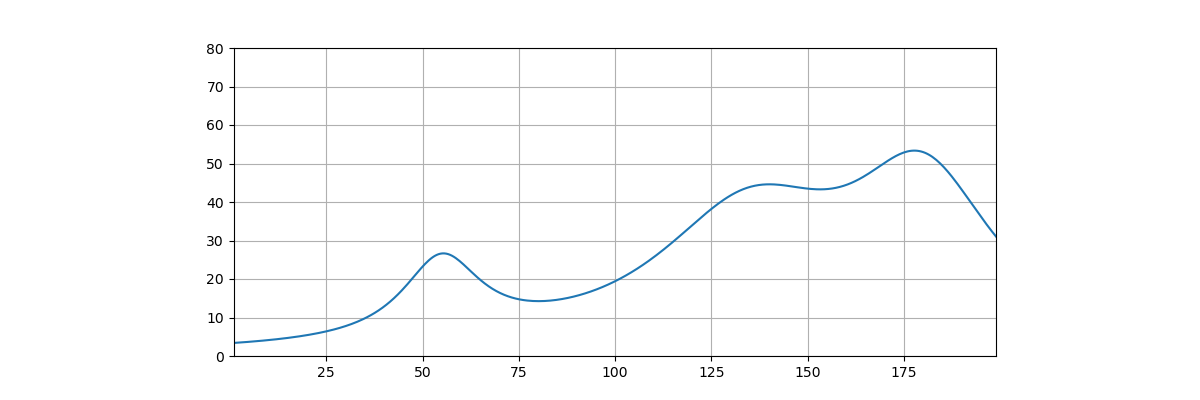

In [3]:
xs = np.linspace(0, 200, 400)
fs = univariate_peak([12.0, 35.0, 22.0], [55.0, 135.0, 180.0], [25.0, 60.0, 45.0])

fig, ax = plt.subplots(figsize=(12, 4))
line, = ax.plot(xs, fs(x))
ax.set_aspect('equal')
ax.set_xlim(1,199)
ax.set_ylim(0, 80)
ax.grid(True)

h1 = widgets.FloatSlider(description="Height 1", min=2.0, max=60.0, value=21.0)
c1 = widgets.FloatSlider(description="Center 1", min=-50.0, max=250.0,value=55.0)
w1 = widgets.FloatSlider(description="Width 1", min=1.0, max=150.0, value=25.0)

h2 = widgets.FloatSlider(description="Height 2", min=2.0, max=60.0, value=35.0)
c2 = widgets.FloatSlider(description="Center 2", min=-50.0, max=250.0, value=135.0)
w2 = widgets.FloatSlider(description="Width 2", min=1.0, max=150.0, value=60.0)

h3 = widgets.FloatSlider(description="Height 3", min=2.0, max=60.0, value=42.0)
c3 = widgets.FloatSlider(description="Center 3", min=-50.0, max=250.0, value=180.0)
w3 = widgets.FloatSlider(description="Width 1", min=1.0, max=150.0, value=45.0)

ui = widgets.HBox([widgets.VBox([h1, c1, w1]), widgets.VBox([h2, c2, w2]), widgets.VBox([h3, c3, w3])])

def update_sum_plot(h1, c1, w1, h2, c2, w2, h3, c3, w3):
    fs = univariate_peak([h1,h2,h3], [c1,c2,c3], [w1,w2,w3])
    line.set_ydata(fs(xs))
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

out = widgets.interactive_output(update_sum_plot, {'c1': c1, 'h1': h1, 'w1': w1, 'c2': c2, 'h2': h2, 'w2': w2, 'c3': c3, 'h3': h3, 'w3': w3})
display(ui, out)